### 오늘 논의할 세 가지
1. 주안역세권·신기시장·인하대후문의 **분석 범위**가 정책 대상과 맞는가?
2. **업종 구성과 관련 동의 주민 연령**에서 어떤 차이가 관측되는가?
3. 소비자료와 현장 확인으로 **어떤 가설을 검증할 것인가?**

**핵심:** 500m 임시 반경의 점포 수는 주안역세권 2,154개, 신기시장 1,087개, 인하대후문 783개다. 관련 동에서는 신기시장 주변의 고령층, 인하대후문 주변의 젊은 성인과 고령층 수요를 함께 검토할 필요가 있다. 방문객·매출·지원 우선순위는 아직 판단하지 않는다.



In [ ]:
from pathlib import Path
import json, html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display, HTML, Image
ROOT=Path.cwd()
if not (ROOT/'data/raw').exists(): ROOT=ROOT/'Commercial district analysis'
OUT=ROOT/'outputs'
for font in ['AppleGothic','Malgun Gothic','NanumGothic']:
    if any(f.name==font for f in fm.fontManager.ttflist):
        plt.rcParams['font.family']=font; break
plt.rcParams.update({'axes.unicode_minus':False,'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False})
ZONES=['주안역세권','신기시장','인하대후문']
COLORS=['#2563eb','#d97706','#059669']
summary=pd.read_csv(OUT/'zone_summary.csv')
lq=pd.read_csv(OUT/'zone_lq.csv')
zone_stores=pd.read_csv(OUT/'zone_stores.csv',dtype={'adongCd':str})
centers=pd.read_csv(OUT/'zone_centers.csv').set_index('zone').loc[ZONES]
bus=pd.read_csv(OUT/'bus_matched.csv')
context=pd.read_csv(OUT/'zone_dong_population_context.csv')
pop=pd.read_csv(OUT/'population_dong_summary.csv',dtype={'dong_code':str,'month':str})
age=pd.read_csv(OUT/'population_age_1year.csv',dtype={'dong_code':str,'month':str})
raw=json.loads((ROOT/'data/raw/district_stores.json').read_text())
assert raw['complete'] and len(raw['rows'])==raw['total']==18885
stores=pd.DataFrame(raw['rows'])
base=summary[summary.radius_m.eq(500)].set_index('zone').loc[ZONES]
assert zone_stores.query('radius_m==500').groupby('zone').size().reindex(ZONES).eq(base.store_count).all()
print('기본 단위: 미추홀구 전체 점포 대비 각 상권의 임시 500m 원형 분석권')


기본 단위: 미추홀구 전체 점포 대비 각 상권의 임시 500m 원형 분석권


## 1. 자료 범위와 분석의 한계

| 자료 | 기준시점 | 범위·상태 | 해석 한계 |
|---|---|---|---|
| 상가업소 | 2026년 6월 | 구 전체 18,885개, 완전 수집 | 제공기관에 포착된 영업 점포; 공실·폐업률 아님 |
| 버스 승하차 | 2026년 6월 | 원본 6,760행 중 6,521행 좌표 매칭 | 버스 이용이며 고유 방문자 수 아님; 철도 제외 |
| 버스 위치 | 2025년 10월 31일 | 인천BIS 번호+명칭 정확 결합 | 승하차 시점과 차이, 미매칭 239행 |
| 시장 대표점 | 제공 페이지 2024년 10월 31일 | 신기시장 대표점 | 시장 경계 폴리곤 아님 |
| 주민등록인구 | 2026년 6월·8월 | 구 합계+21개 동, 전 연령·남녀 검증 | 동 전체 주민; 상권 거주자·방문객 아님 |
| 카드매출·유동인구·공실 | 미확보 | 이번 분석 제외 | 소비전환·사업효과·지원순위 판단 보류 |

인구는 8월을 최신 현황, 6월을 점포·승하차와 동시점 비교 기준으로 사용한다. 상권 중심은 시장 대표점 또는 버스 진입점 평균이며 담당 부서와 확정한 경계가 아니다.


## 2. 실제 지도 오버레이 — 먼저 범위를 확인

상권별 점포·버스정류장·시장 대표점을 도로·철도·대학 위치와 함께 살펴본다. 500m를 기준으로 300m·1km 반경을 비교한다.

지도 배경은 현재 OpenStreetMap이며, 점포·교통자료의 기준시점과 다르다. 행정동 경계를 확보하지 않아 인구를 지도 면적으로 표현하지 않는다.


In [ ]:
def distance_m(lat,lon,center):
    a,b=np.radians(np.asarray(lat,dtype=float)),np.radians(np.asarray(lon,dtype=float))
    c,d=np.radians(center)
    h=np.sin((a-c)/2)**2+np.cos(a)*np.cos(c)*np.sin((b-d)/2)**2
    return 6371000*2*np.arcsin(np.sqrt(np.clip(h,0,1)))
map_stores=zone_stores.query('radius_m==1000').copy()
map_stores['in500']=[bool(distance_m(row.lat,row.lon,centers.loc[row.zone,['lat','lon']].to_numpy())<=500) for row in map_stores.itertuples()]
near_bus=np.zeros(len(bus),dtype=bool)
for z in ZONES:near_bus |= distance_m(bus.lat,bus.lon,centers.loc[z,['lat','lon']].to_numpy())<=1000
map_payload=dict(centers=centers.reset_index()[['zone','lat','lon']].to_dict('records'),colors=COLORS,
 stores=map_stores[['zone','lat','lon','bizesNm','indsMclsNm','indsSclsNm','rdnmAdr','in500']].fillna('').to_dict('records'),
 bus=bus.loc[near_bus,['lat','lon','정류장명','daily_passengers']].to_dict('records'),
 markets=json.loads((ROOT/'data/raw/market.json').read_text())['rows'])
map_template='<!doctype html><html lang="ko"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1"><title>미추홀구 상권 검토 지도</title><link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"><style>body{margin:0;font:15px system-ui;color:#17243b}header{padding:14px 20px;background:#f3f6fa}h1{font-size:20px;margin:0 0 8px}p{margin:6px 0;font-size:13px}button{padding:7px 12px;margin:4px;border:1px solid #bcc6d4;background:white;border-radius:6px;cursor:pointer}button:focus{outline:3px solid #2563eb}#map{height:650px}#status{color:#664d03} .legend{background:white;padding:10px;line-height:1.7;box-shadow:0 1px 5px #888}</style></head><body><header><h1>미추홀구 · 상권별 공간 분포</h1><p>점포·승하차 2026.06 / 정류장 위치 2025.10 / 원형 반경은 정책 경계·보행권이 아닙니다.</p><nav id="zones" aria-label="상권 이동"></nav><p id="status">배경지도 로딩 중 · 인터넷 연결 필요</p></header><div id="map" aria-label="상권 점포와 버스정류장 지도"></div><script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script><script>\nconst D=__DATA__;\nconst esc=x=>String(x??\'\').replace(/[&<>"\']/g,c=>({\'&\':\'&amp;\',\'<\':\'&lt;\',\'>\':\'&gt;\',\'"\':\'&quot;\',"\'":\'&#39;\'}[c]));\nconst map=L.map(\'map\',{preferCanvas:true}).setView([37.455,126.669],14);\nconst tiles=L.tileLayer(\'https://tile.openstreetmap.org/{z}/{x}/{y}.png\',{maxZoom:19,attribution:\'&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors\'}).addTo(map);\ntiles.on(\'load\',()=>document.getElementById(\'status\').textContent=\'배경지도 로딩 완료 · 점포는 클릭하여 상세 확인\');\ntiles.on(\'tileerror\',()=>document.getElementById(\'status\').textContent=\'일부 지도 타일 로딩 실패 · 인터넷 연결 확인\');\nconst groups={},circles=L.layerGroup().addTo(map),small=L.layerGroup(),large=L.layerGroup(),stops=L.layerGroup(),markets=L.layerGroup();\nfor(const [i,z] of D.centers.entries()){\n const color=D.colors[i];groups[z.zone+\' · 500m 점포\']=L.layerGroup().addTo(map);groups[z.zone+\' · 1km 점포\']=L.layerGroup();\n L.circle([z.lat,z.lon],{radius:500,color,fillOpacity:.035,weight:3}).bindTooltip(esc(z.zone)+\' · 임시 500m\').addTo(circles);\n L.circle([z.lat,z.lon],{radius:300,color,fill:false,dashArray:\'4 5\',weight:1}).addTo(small);\n L.circle([z.lat,z.lon],{radius:1000,color,fill:false,dashArray:\'8 6\',weight:1}).addTo(large);\n L.circleMarker([z.lat,z.lon],{radius:7,color,fillOpacity:1}).bindTooltip(esc(z.zone),{permanent:true,direction:\'top\'}).addTo(circles);\n const b=document.createElement(\'button\');b.textContent=z.zone;b.onclick=()=>map.setView([z.lat,z.lon],16);document.getElementById(\'zones\').append(b);\n}\nfor(const s of D.stores){const i=D.centers.findIndex(c=>c.zone===s.zone);const marker=L.circleMarker([s.lat,s.lon],{radius:3,weight:0,fillColor:D.colors[i],fillOpacity:.65}).bindPopup(\'<b>\'+esc(s.bizesNm)+\'</b><br>\'+esc(s.indsMclsNm)+\' / \'+esc(s.indsSclsNm)+\'<br>\'+esc(s.rdnmAdr));marker.addTo(groups[s.zone+\' · 1km 점포\']);if(s.in500)L.circleMarker([s.lat,s.lon],{radius:3,weight:0,fillColor:D.colors[i],fillOpacity:.8}).bindPopup(marker.getPopup().getContent()).addTo(groups[s.zone+\' · 500m 점포\']);}\nfor(const b of D.bus)L.circleMarker([b.lat,b.lon],{radius:Math.max(3,Math.min(13,Math.sqrt(b.daily_passengers)/8)),color:\'#6d28d9\',weight:1,fillOpacity:.45}).bindPopup(\'<b>\'+esc(b[\'정류장명\'])+\'</b><br>일평균 승하차 \'+Number(b.daily_passengers).toLocaleString()+\'건<br>2026.06, 방문자 수 아님\').addTo(stops);\nfor(const m of D.markets)L.circleMarker([Number(m[\'위도\']),Number(m[\'경도\'])],{radius:7,color:\'#111827\',fillColor:\'#fff\',fillOpacity:1}).bindPopup(esc(m[\'시장명\'])+\'<br>\'+esc(m[\'도로명주소\'])).addTo(markets);\nL.control.layers(null,{...groups,\'임시 500m 반경·중심\':circles,\'300m 비교 반경\':small,\'1km 비교 반경\':large,\'버스 승하차 (원 크기)\':stops,\'시장 대표점\':markets},{collapsed:false}).addTo(map);\nL.control.scale({imperial:false}).addTo(map);\nconst all=document.createElement(\'button\');all.textContent=\'전체 보기\';all.onclick=()=>map.fitBounds(D.centers.map(c=>[c.lat,c.lon]),{padding:[100,100]});document.getElementById(\'zones\').prepend(all);all.click();\nwindow.reportMap=map;window.reportLayers=groups;window.reportData=D;\n</script></body></html>'
map_html=map_template.replace('__DATA__',json.dumps(map_payload,ensure_ascii=False,allow_nan=False).replace('<','\u003c'))
(OUT/'briefing_map.html').write_text(map_html,encoding='utf-8')
display(HTML('<iframe title="미추홀구 상권 지도" width="100%" height="850" style="border:1px solid #ddd" srcdoc="'+html.escape(map_html,quote=True)+'"></iframe>'))


/Users/USER/vscode/Incheon-Public-Data-Analysis/Commercial district analysis/.venv/lib/python3.11/site-packages/IPython/core/display.py:448: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## 3. 점포 규모·다양성과 반경 민감도

점포 수는 규모, Shannon 엔트로피는 업종 구성의 다양성을 나타낸다. 다양성이 높다는 것이 더 우수한 상권이라는 뜻은 아니다. 반경을 바꿔도 규모의 순서가 유지되는지 확인한다. 분석 반경 안의 구 밖 점포는 제외한다.


,점포 수,업종 다양성 H,정규화 다양성
zone,,,
주안역세권,2154,3.484,0.810
신기시장,1087,3.163,0.735
인하대후문,783,3.228,0.750


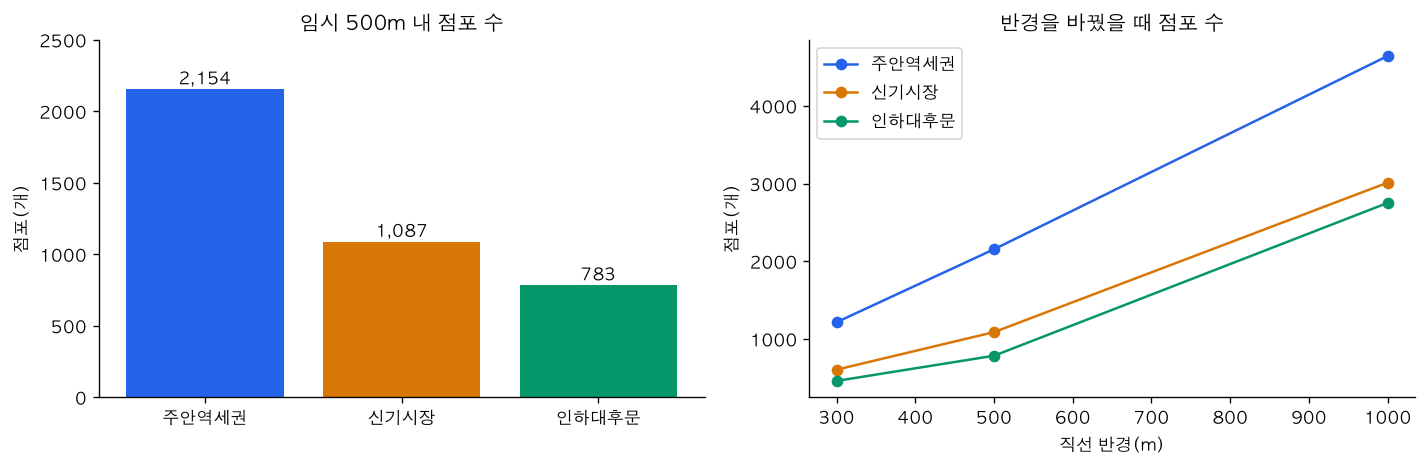

In [ ]:
display(base[['store_count','entropy','normalized_entropy']].rename(columns={'store_count':'점포 수','entropy':'업종 다양성 H','normalized_entropy':'정규화 다양성'}).round(3))
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].bar(ZONES,base.store_count,color=COLORS)
for i,v in enumerate(base.store_count):axes[0].text(i,v+35,f'{v:,}',ha='center')
axes[0].set_title('임시 500m 내 점포 수');axes[0].set_ylabel('점포(개)');axes[0].set_ylim(0,2500)
for z,color in zip(ZONES,COLORS):
    t=summary[summary.zone.eq(z)].sort_values('radius_m')
    axes[1].plot(t.radius_m,t.store_count,'o-',label=z,color=color)
axes[1].set_title('반경을 바꿨을 때 점포 수');axes[1].set_xlabel('직선 반경(m)');axes[1].set_ylabel('점포(개)');axes[1].legend()
fig.tight_layout();fig.savefig(OUT/'briefing_store_scale.png',dpi=180);plt.show()


## 4. 어떤 업종으로 구성돼 있는가?

업종 구성비는 세 상권 모두 같은 대분류로 비교한다. LQ는 중분류 기준으로, **미추홀구 전체에서의 비중 대비 상권 내 비중**이다. LQ 2는 구성비가 구 평균의 2배라는 뜻이며 매출·과밀의 증거가 아니다. 희소 업종 해석을 줄이기 위해 아래 표는 상권 점포 10개 이상만 보여준다.


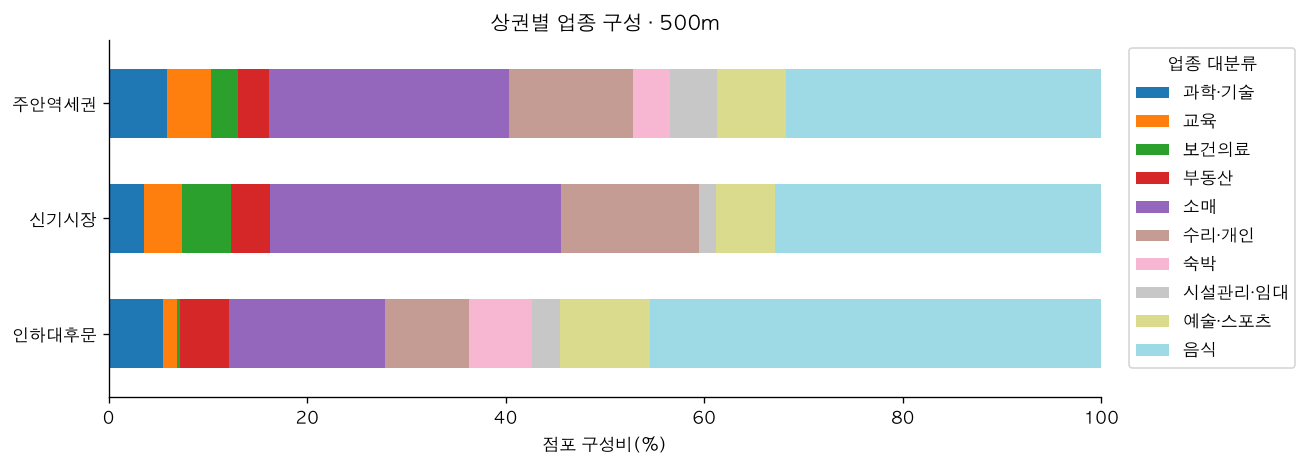

,상권,업종 중분류,상권 점포,구 전체 점포,LQ
354,신기시장,의원,53,443,2.08
299,신기시장,식료품 소매,78,667,2.03
358,신기시장,유원지·오락,48,570,1.46
309,신기시장,의약·화장품 소매,35,431,1.41
365,신기시장,이용·미용,117,1474,1.38
392,인하대후문,기타 숙박,42,107,9.47
430,인하대후문,도서관·사적지,16,68,5.68
396,인하대후문,서양식,20,105,4.59
408,인하대후문,기술 서비스,13,153,2.05
394,인하대후문,중식,19,229,2.00


숙박·도서관 등 분류는 세부업종·실제 점포를 확인한 뒤 정책 언어로 해석합니다.


In [ ]:
s500=zone_stores.query('radius_m==500')
composition=pd.crosstab(s500.zone,s500.indsLclsNm).reindex(ZONES).fillna(0)
composition=composition.div(composition.sum(axis=1),axis=0)*100
ax=composition.plot.barh(stacked=True,figsize=(11,4),colormap='tab20',width=.6)
ax.set_xlabel('점포 구성비(%)');ax.set_ylabel('');ax.set_xlim(0,100);ax.invert_yaxis()
ax.legend(title='업종 대분류',bbox_to_anchor=(1.02,1),loc='upper left');ax.set_title('상권별 업종 구성 · 500m')
plt.tight_layout();plt.savefig(OUT/'briefing_category_mix.png',dpi=180);plt.show()
top=lq.query('radius_m==500 and store_count>=10').sort_values(['zone','LQ'],ascending=[True,False]).groupby('zone').head(5)
display(top[['zone','category_name','store_count','district_count','LQ']].rename(columns={'zone':'상권','category_name':'업종 중분류','store_count':'상권 점포','district_count':'구 전체 점포'}).round(2))
print('숙박·도서관 등 분류는 세부업종·실제 점포를 확인한 뒤 정책 언어로 해석합니다.')


## 5. 관련 동의 주민 연령구조는 어떻게 다른가?

미추홀구 8월 총인구는 419,123명으로 6월 대비 912명(+0.218%) 증가했다. 두 달 변화만으로 장기 추세를 말할 수 없다.

각 상권의 500m 내 점포가 가장 많이 소재한 행정동을 대표 **예시**로 비교한다. 관련된 다른 동은 아래 표에 모두 표시한다. 20~39세는 분석용 연령구간이고, 대학생 수나 법정 청년인구가 아니다. 65세 이상 비중과 함께 보면 세대가 섞인 지역도 확인할 수 있다.

**수요 해석의 범위:** 주민 연령구조는 구매수요를 추정하기 위한 단서다. 실제 이용 연령·구매품목·구매처는 방문객 조사와 소비자료로 별도 확인한다.


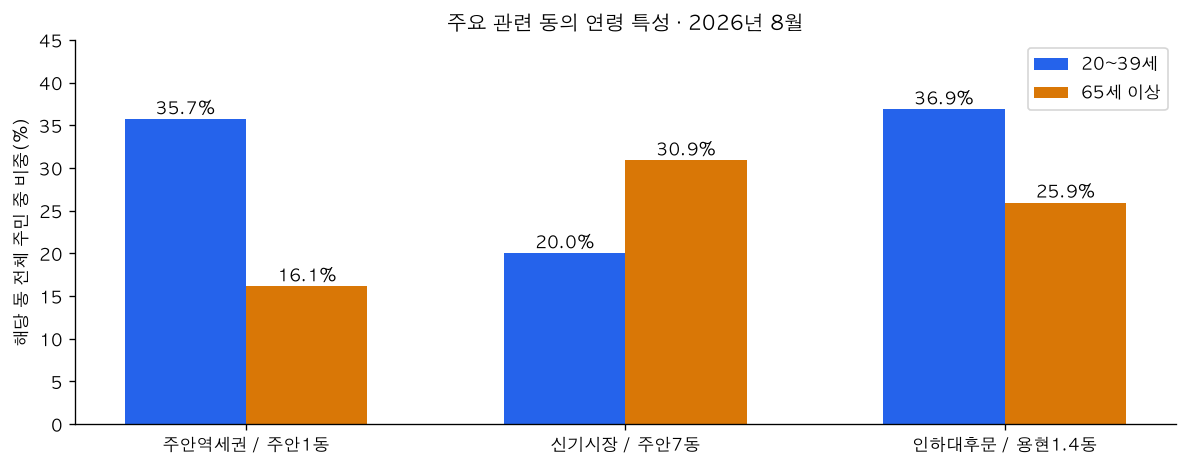

,상권,관련 동,반경 내 점포,상권 점포 중 비중(%),동 전체 인구,20~39세(%),65세 이상(%)
0,주안역세권,도화1동,19,0.88,20271,24.58,24.00
1,주안역세권,주안1동,1566,72.70,19903,35.70,16.12
2,주안역세권,주안5동,569,26.42,18917,26.43,24.96
3,신기시장,학익2동,24,2.21,17534,22.41,26.92
4,신기시장,주안3동,66,6.07,12045,24.72,24.25
5,신기시장,주안7동,787,72.40,12020,20.00,30.87
6,신기시장,주안8동,210,19.32,18365,21.13,27.07
7,인하대후문,용현1.4동,743,94.89,17171,36.85,25.93
8,인하대후문,용현3동,38,4.85,6519,23.42,34.18
9,인하대후문,학익1동,2,0.26,41456,25.64,16.53


In [ ]:
main=context.sort_values('zone_store_count',ascending=False).drop_duplicates('zone').set_index('zone').loc[ZONES]
fig,ax=plt.subplots(figsize=(10,4))
x=np.arange(3);w=.32
ax.bar(x-w/2,main.age_20_39_pct,w,label='20~39세',color='#2563eb')
ax.bar(x+w/2,main.age_65_plus_pct,w,label='65세 이상',color='#d97706')
for pos,values in [(x-w/2,main.age_20_39_pct),(x+w/2,main.age_65_plus_pct)]:
    for a,v in zip(pos,values):ax.text(a,v+.6,f'{v:.1f}%',ha='center')
ax.set_xticks(x,[z+' / '+main.loc[z,'adongNm'] for z in ZONES]);ax.set_ylim(0,45)
ax.set_ylabel('해당 동 전체 주민 중 비중(%)');ax.set_title('주요 관련 동의 연령 특성 · 2026년 8월');ax.legend()
fig.tight_layout();fig.savefig(OUT/'briefing_population.png',dpi=180);plt.show()
display(context[['zone','adongNm','zone_store_count','zone_store_share_pct','total_population','age_20_39_pct','age_65_plus_pct']].rename(columns={'zone':'상권','adongNm':'관련 동','zone_store_count':'반경 내 점포','zone_store_share_pct':'상권 점포 중 비중(%)','total_population':'동 전체 인구','age_20_39_pct':'20~39세(%)','age_65_plus_pct':'65세 이상(%)'}).round(2))


## 6. 버스 접근성은 참고지표로만 비교

일평균 승하차에 중심으로부터의 거리 감쇠를 적용한 값이다. 직선거리 1km 이내, β=0.0015/m를 기본으로 사용한다. 통근·환승·통과 목적이 섞여 있어 상권 유입인구나 소비전환율로 해석할 수 없다. 특히 주안역 비교에는 **철도 승하차가 포함되지 않았다.**


In [ ]:
access=pd.read_csv(OUT/'bus_accessibility_provisional.csv')
a=access[np.isclose(access.beta_per_m,.0015)].set_index('zone').loc[ZONES]
display(a[['matched_stops','weighted_daily_board_alight','weighted_daily_alight']].rename(columns={'matched_stops':'매칭 정류장 수(1km)','weighted_daily_board_alight':'거리감쇠 일평균 승하차','weighted_daily_alight':'거리감쇠 추정 일평균 하차'}).round(1))


,매칭 정류장 수(1km),거리감쇠 일평균 승하차,거리감쇠 추정 일평균 하차
zone,,,
주안역세권,64,35018.9,16942.1
신기시장,85,21357.0,10520.3
인하대후문,58,20192.1,9937.5


## 7. 기초진단을 현장 점검 과제로 연결

상권 유형에 맞는 활성화 방향을 찾기 위해 공개자료로 업종 구조·주민 연령구조·교통 접근성을 살펴봤다. 다음 카드는 관측 사실을 근거로 **어디를 확인하고, 무엇이 확인될 때 어떤 조치를 검토할지** 제시한다.

현재 현장조사는 미실시다. 아래 경로는 지도에서 협의할 후보이며, 이동 장애·이용 불편·소비 특성이 이미 확인됐다는 뜻이 아니다. 업종 특화는 미추홀구 전체 대비, 점포 수는 임시 500m 반경, 인구는 2026년 8월 관련 동 전체 기준이다.


### 7-1. 주안역세권 — 역과 상업거리의 연결을 확인

| 구분 | 보고 내용 |
|---|---|
| **관측 사실** | 500m 점포 2,154개. 세 후보 중 점포 수·업종 다양성이 가장 높음. 주요 관련 동인 주안1동의 20~39세 비중은 35.7%. 철도 승하차는 미포함. |
| **검토 가설** | 역 출입구·지하상가·지상 골목 사이의 이동 여건이 상권 이용에 영향을 줄 수 있음. 현재 자료로 연결이 나쁘거나 소비전환이 낮다고 판정하지 않음. |
| **현장 경로 후보** | ① 역 출구 → 점포 밀집 골목 ② 지하상가 출입구 → 지상 상업거리. 정확한 출발·도착점은 구청과 지도에서 지정. |
| **관찰 항목** | 보행시간·횡단 횟수·계단과 우회, 출입구 안내, 영업 점포 분포. 통과·체류 여부는 같은 구간에서 동일 시간 길이로 반복 관찰. |
| **조건부 조치** | 안내 누락·이동 불편이 확인되면 표지·연결 동선 개선 후보로 제시. 이동은 편리하지만 체류가 짧게 관측되면 시간대 소비·방문 목적을 추가 조사. |
| **협조 요청** | 지하상가 출입구·점포·운영시간 자료, 역 주변 기존 개선사업, 철도 이용자료 확보 경로. |



### 7-2. 신기시장 — 생활구매 동선과 이용 편의를 확인

| 구분 | 보고 내용 |
|---|---|
| **관측 사실** | 500m 점포 1,087개. 식료품 소매 78개(LQ 약 2.03), 의원 53개(LQ 약 2.08). 주요 관련 동인 주안7동의 65세 이상 비중은 30.9%. |
| **검토 가설** | 시장·의원·주변 점포가 생활 목적의 연계 이용에 기여할 수 있음. 고령 주민 비중만으로 실제 시장 고객층이나 추가 의료시설 수요를 단정하지 않음. |
| **현장 경로 후보** | ① 정류장 → 시장 입구 ② 시장 입구 → 주변 의원·생활점포. 이용자가 실제 선택하는 경로인지 확인. |
| **관찰 항목** | 보도 폭·턱·경사·횡단 대기, 적치물·휴식공간·안내. 자발적 응답자를 대상으로 방문 목적·이동수단·함께 이용한 장소를 짧게 질문. |
| **조건부 조치** | 반복되는 이동 불편이 확인되면 접근·편의 개선 후보로 제시. 시장과 주변 점포의 연계 이용이 확인되면 공동 안내·연계사업 검토. 업종 유치는 기존 공급·이용 불편을 추가 확인한 뒤 판단. |
| **협조 요청** | 공식 시장 범위, 기존 시설·편의 개선사업, 상인회가 파악한 이용 불편과 연계사업 이력. |



### 7-3. 인하대후문 — 학생 이용과 주민 생활을 함께 확인

| 구분 | 보고 내용 |
|---|---|
| **관측 사실** | 500m 점포 783개. 서양식 20개(LQ 약 4.59), 기타 숙박 42개(LQ 약 9.47). 주요 관련 동인 용현1.4동의 20~39세 비중은 36.9%, 65세 이상은 25.9%. |
| **검토 가설** | 대학 관련 소비와 주민 생활수요가 장소·시간대별로 다를 수 있음. 젊은 주민을 모두 학생으로 보거나 숙박 분류를 실제 용도 확인 없이 해석하지 않음. |
| **현장 경로 후보** | ① 대학 후문 → 음식점 밀집 거리 ② 후문 상업거리 → 주거 골목. 인하대역 일대까지 분석할지 별도 협의. |
| **관찰 항목** | 평일 점심·저녁과 주말에 같은 경로·관찰시간으로 영업 상태·보행 상황 기록. 방문 목적을 짧게 조사하고, 기타 숙박의 세부업종·실제 운영 형태 확인. |
| **조건부 조치** | 시간대·목적별 차이가 반복 확인되면 학생 이용거리와 주민 생활거리에 맞는 운영·사업 방향 검토. 학기·방학 대응은 해당 기간 자료 확보 후 판단. |
| **협조 요청** | 대학 출입구·운영 여건, 청년·생활상권 기존 사업, 상인 의견과 가능하면 학기·방학 소비자료. |



## 8. 공통 현장 점검표 — 관측과 해석을 분리

조사 위치와 시간을 먼저 정하고 **같은 경로·같은 관찰시간**으로 비교한다. 첫 방문은 후보 문제를 찾는 탐색 조사이며 일반화하지 않는다. 필요 구간은 다른 요일·시간대에 재방문한다.

| 기록 항목 | 작성 내용 | 확인 기준 |
|---|---|---|
| 구간 ID·지도 위치 | 상권명 / 출발점 / 도착점 / 지도 번호 | 정확한 경로를 재방문할 수 있는가 |
| 조사 조건 | 날짜·요일·시각·관찰시간·날씨·행사 여부 | 시간대·외부 조건 차이를 기록했는가 |
| 접근성 | 실제 보행시간·횡단 횟수·대기시간·계단·우회 | 수치와 실제 관측 위치를 적었는가 |
| 보행·안내·편의 | 좁은 보도·턱·경사·적치물·표지·휴식공간 | 불편의 위치와 관측 근거가 있는가 |
| 점포 운영 | 관찰 구간의 영업 중·닫힘·확인 불가 | 닫힌 점포를 폐업·공실로 단정하지 않았는가 |
| 이용 상황 | 정한 지점의 동일 시간대 통행·머무름 관찰 | 외모로 연령·학생 여부를 분류하지 않았는가 |
| 짧은 이용자 의견 | 자발적 응답자의 방문 목적·이동수단·연계 이용·불편 | 응답 수를 기록하고 대표성 한계를 밝혔는가 |
| 근거·해석·후속 | 위치 사진 / 관측 사실 / 해석 가설 / 추가 확인 | 사진은 시설·동선 중심으로 남겼는가 |

### 기록 예시의 형식 — 조사 결과가 아닌 빈 서식

- 구간 ID / 상권 / 조사일시 / 조사자: __________
- 출발 → 도착 / 지도 위치 / 날씨·행사: __________
- 관측 사실과 측정값 / 사진 번호: __________
- 가능한 해석 / 다른 설명 가능성: __________
- 필요한 추가 확인 / 담당 부서 확인사항: __________
- 조치 검토 조건 / 우선 재점검 여부와 이유: __________

**조치 선택 원칙:** 한 번의 관찰로 사업을 확정하지 않는다. 위치·반복성·이용자 의견이 뒷받침된 문제부터 담당 부서의 시행 가능성과 기존 사업을 확인한다.


## 9. 내일 회의에서 결정·요청할 사항

1. **범위:** 지도에서 세 상권의 중심·주요 골목·출입구와 제외 구역 확인. 인하대역과 후문을 한 상권으로 볼지 별도 분석할지도 결정.
2. **정책 목적:** 방문 확대, 체류·구매 전환, 생활편의, 고령 이용자 접근 개선 중 우선 목적 확인.
3. **구청 협조자료:** 상권·시장 공식 경계, 지하상가 점포 목록, 기존 행사·시설개선·지원사업 위치와 기간, 가능한 현장·공실 자료.
4. **카드자료:** 맞춤 상권/행정동 등 공간단위, 월·요일·시간대, 업종·연령별 금액/건수 제공 여부 확인. 행정동 자료로 골목 매출을 단정하지 않기.
5. **다음 산출물:** 확정 경계 기준 재집계 → 경로별 현장 점검 → 소비자료로 가설 검증 → 실행전략.

### 자료 출처
- [소상공인시장진흥공단 상가정보](https://www.data.go.kr/data/15012005/openapi.do)
- [버스 승하차](https://www.data.go.kr/data/15048264/fileData.do) · [정류장 위치](https://www.data.go.kr/data/15067528/fileData.do)
- [미추홀구 재래시장](https://www.data.go.kr/data/15087058/fileData.do) · [행정안전부 연령별 주민등록인구](https://jumin.mois.go.kr/ageStatMonth.do)
- 배경지도: © OpenStreetMap contributors.



In [ ]:
# 보고용 최소 일관성 검증: 집계·분류·지도 범위·인구 범위
assert np.allclose(composition.sum(axis=1),100)
assert sum(s['in500'] for s in map_payload['stores'])==int(base.store_count.sum())
assert set(context.zone)==set(ZONES)
assert set(pop.month)=={'202606','202608'}
assert len(age)==13332
assert not age.duplicated(['month','dong_code','sex','age_lower']).any()
assert pop.query("month=='202608' and dong_code=='2817700000'").total_population.iloc[0]==419123
assert all(np.isfinite(s['lat']) and np.isfinite(s['lon']) for s in map_payload['stores'])
